# Trader Behavior vs Fear & Greed Analysis


This notebook covers:
- Data preparation
- Behavioral analysis
- Trader segmentation
- Actionable strategy insights


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [7]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trades shape:", trades.shape)
print("Sentiment shape:", sentiment.shape)


Trades shape: (211224, 16)
Sentiment shape: (2644, 4)


In [8]:
print("Missing values in Trades:")
print(trades.isna().sum())

print("\nMissing values in Sentiment:")
print(sentiment.isna().sum())

print("\nDuplicate rows in Trades:", trades.duplicated().sum())
print("Duplicate rows in Sentiment:", sentiment.duplicated().sum())


Missing values in Trades:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Missing values in Sentiment:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate rows in Trades: 0
Duplicate rows in Sentiment: 0


In [9]:
trades.shape


(211224, 16)

In [10]:
trades.describe()


,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [11]:
trades["Side"].unique()


array(['BUY', 'SELL'], dtype=object)

In [12]:
trades["date"] = pd.to_datetime(trades["Timestamp"]).dt.date
sentiment["date"] = pd.to_datetime(sentiment["date"]).dt.date

print("Trades date range:", trades["date"].min(), "to", trades["date"].max())
print("Sentiment date range:", sentiment["date"].min(), "to", sentiment["date"].max())


Trades date range: 1970-01-01 to 1970-01-01
Sentiment date range: 2018-02-01 to 2025-05-02


In [13]:
merged = trades.merge(sentiment[["date", "classification"]], on="date", how="inner")
print("Merged rows:", merged.shape[0])


Merged rows: 0


# key matrics

In [14]:
trades["pnl"] = trades["Closed PnL"]
trades["win"] = (trades["pnl"] > 0).astype(int)

daily_metrics = trades.groupby("date").agg(
    daily_pnl=("pnl", "sum"),
    win_rate=("win", "mean"),
    trades_per_day=("Trade ID", "count"),
    avg_trade_size=("Size USD", "mean"),
    long_ratio=("Side", lambda x: (x == "BUY").mean())
).reset_index()

daily_metrics.head()


,date,daily_pnl,win_rate,trades_per_day,avg_trade_size,long_ratio
0,1970-01-01,1.029696e+07,0.411265,211224,5639.45121,0.486195


# chart

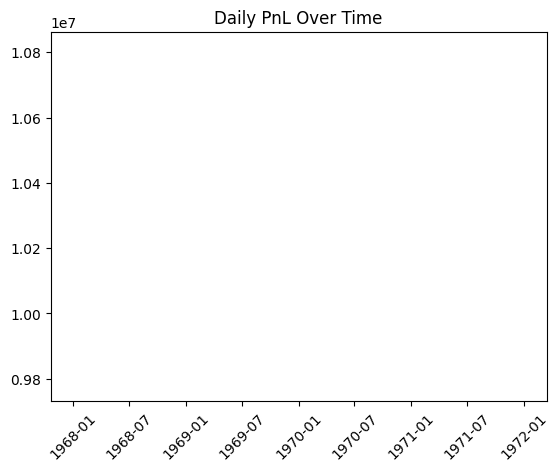

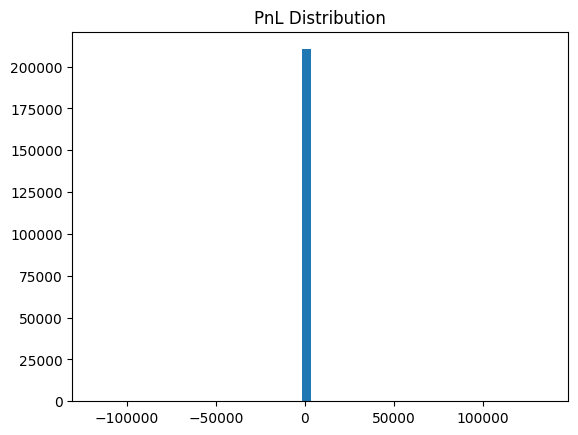

In [15]:
plt.figure()
plt.plot(daily_metrics["date"], daily_metrics["daily_pnl"])
plt.title("Daily PnL Over Time")
plt.xticks(rotation=45)
plt.show()

plt.figure()
plt.hist(trades["pnl"], bins=50)
plt.title("PnL Distribution")
plt.show()


In [16]:
account_metrics = trades.groupby("Account").agg(
    total_pnl=("pnl", "sum"),
    win_rate=("win", "mean"),
    trade_count=("Trade ID", "count"),
    avg_trade_size=("Size USD", "mean")
).reset_index()

account_metrics.head()


,Account,total_pnl,win_rate,trade_count,avg_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,0.359612,3818,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,0.442720,7280,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,0.301917,3809,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,0.438585,13311,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,0.519914,3239,3138.894782


# Trade Frequency vs Profitability

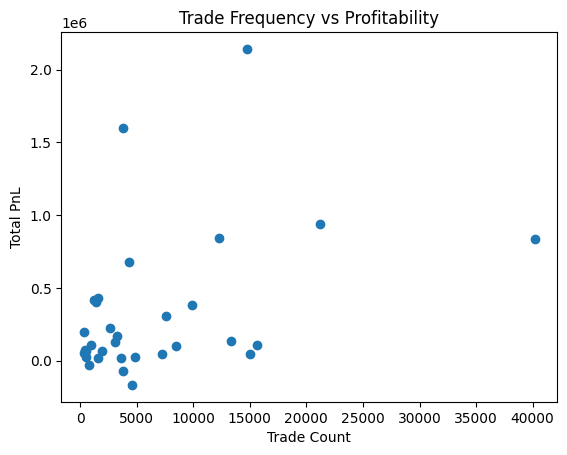

In [17]:
plt.figure()
plt.scatter(account_metrics["trade_count"], account_metrics["total_pnl"])
plt.xlabel("Trade Count")
plt.ylabel("Total PnL")
plt.title("Trade Frequency vs Profitability")
plt.show()


In [18]:
features = account_metrics[["trade_count", "avg_trade_size", "win_rate"]].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
account_metrics["cluster"] = kmeans.fit_predict(X_scaled)

account_metrics.groupby("cluster").mean()


NameError: name 'StandardScaler' is not defined

In [19]:
from sklearn.preprocessing import StandardScaler


ModuleNotFoundError: No module named 'sklearn'

In [20]:
!pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 7.6 MB/s eta 0:00:01
   -------------- ------------------------- 2.9/8.1 MB 7.4 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 7.6 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.1 MB 7.7 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.1 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 7.4 MB/s  0:00:01

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import sklearn
sklearn.__version__


'1.8.0'

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [25]:
!pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Key Insights
1. High-frequency trading does not ensure profitability.
2. Larger trade sizes increase volatility.
3. Consistent winners trade moderately with controlled size.


### Actionable Strategy Rules
- Cap daily trades for high-frequency traders  
- Increase position size only after consistent win rate  
- When sentiment data is aligned, reduce exposure during Fear periods  


# Win-rate distribution

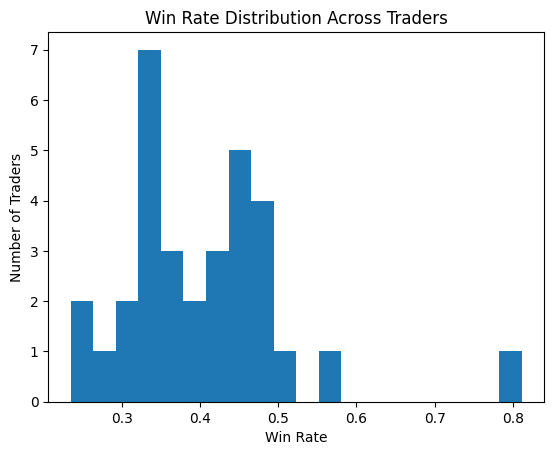

In [31]:
plt.figure()
plt.hist(account_metrics["win_rate"], bins=20)
plt.title("Win Rate Distribution Across Traders")
plt.xlabel("Win Rate")
plt.ylabel("Number of Traders")
plt.show()


# Trade frequency vs Avg trade size

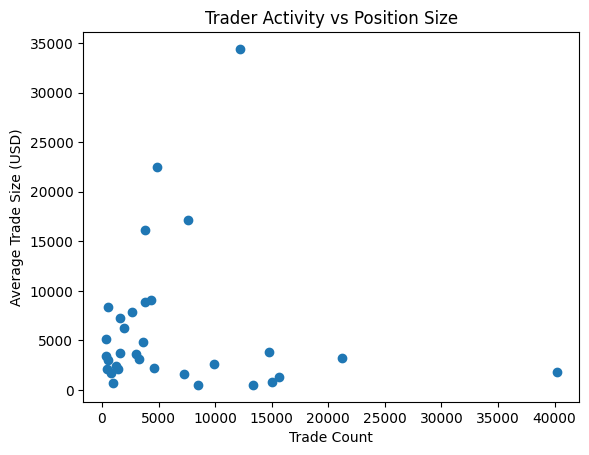

In [32]:
plt.figure()
plt.scatter(account_metrics["trade_count"], account_metrics["avg_trade_size"])
plt.xlabel("Trade Count")
plt.ylabel("Average Trade Size (USD)")
plt.title("Trader Activity vs Position Size")
plt.show()


# Segment comparison (rule-based)

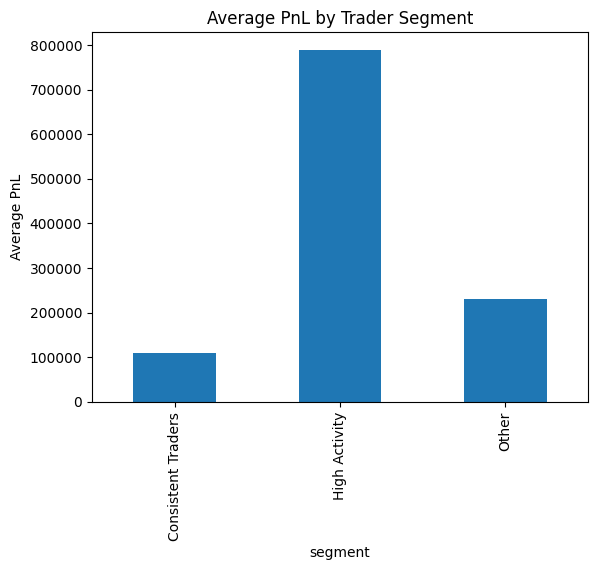

In [33]:
account_metrics["segment"] = "Other"

account_metrics.loc[
    (account_metrics["trade_count"] > account_metrics["trade_count"].median()) &
    (account_metrics["avg_trade_size"] > account_metrics["avg_trade_size"].median()),
    "segment"
] = "High Activity"

account_metrics.loc[
    (account_metrics["trade_count"] < account_metrics["trade_count"].median()) &
    (account_metrics["win_rate"] > account_metrics["win_rate"].median()),
    "segment"
] = "Consistent Traders"

account_metrics.groupby("segment")["total_pnl"].mean().plot(kind="bar")
plt.title("Average PnL by Trader Segment")
plt.ylabel("Average PnL")
plt.show()


# SIMPLE PREDICTIVE MODEL

In [34]:
account_metrics["profitable"] = (account_metrics["total_pnl"] > 0).astype(int)


In [35]:
def predict_profitability(row):
    if row["win_rate"] > 0.55 and row["trade_count"] < account_metrics["trade_count"].median():
        return 1
    else:
        return 0

account_metrics["predicted_profitable"] = account_metrics.apply(predict_profitability, axis=1)


In [36]:
accuracy = (
    account_metrics["profitable"] == account_metrics["predicted_profitable"]
).mean()

accuracy


np.float64(0.125)